In [1]:
#imports 

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from matplotlib.ticker import LogFormatterSciNotation, MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg


# Corr Gaussian

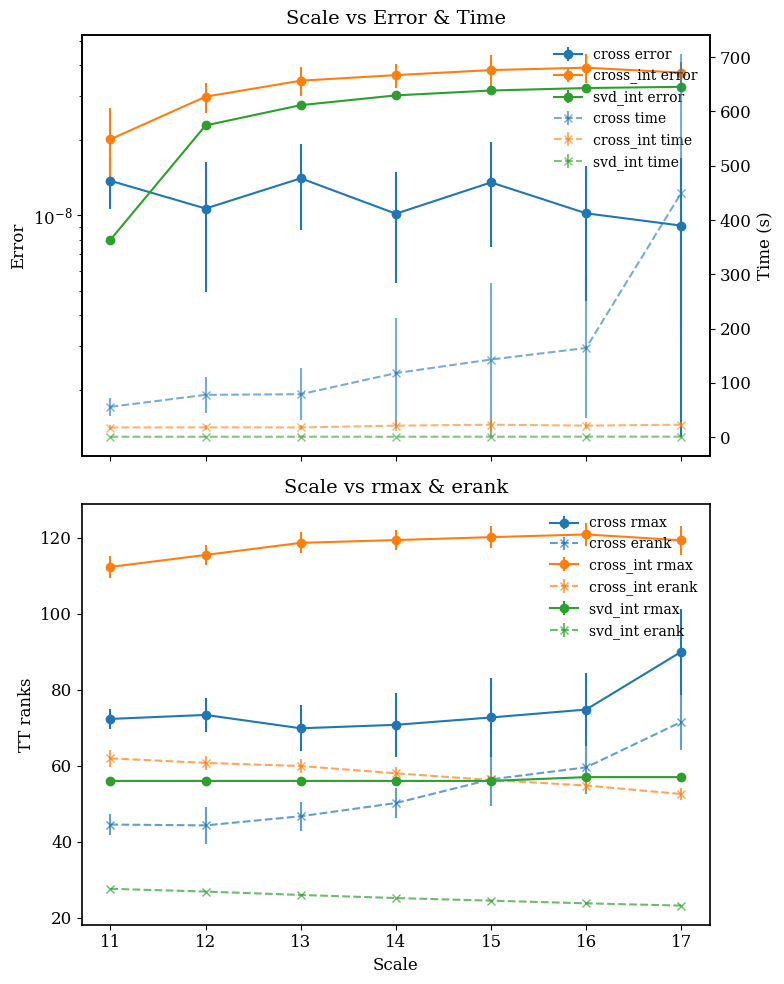

In [23]:
# 1) LaTeX style: serif font + Computer Modern mathtext
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# 2) Load & aggregate
#df = pd.read_csv('./data/corr_gaussian_results.csv')
records = []
with open('./data/corr_gaussian_results_2.jsonl', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:      # skip empty or whitespace-only lines
            continue
        records.append(json.loads(line))

df = pd.DataFrame(records)
stats = (
    df.groupby(['method', 'scale'])
      .agg({
          'error': ['mean', 'std'],
          'time':  ['mean', 'std'],
          'rmax':  ['mean', 'std'],
          'erank': ['mean', 'std']
      })
      .reset_index()
)
stats.columns = [
    'method','scale',
    'error_mean','error_std',
    'time_mean','time_std',
    'rmax_mean','rmax_std',
    'erank_mean','erank_std'
]

methods = stats['method'].unique()
colors = sns.color_palette('tab10', n_colors=len(methods))

# 3) Create 2×1 figure, share x-axis
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
ax2 = ax1.twinx()

# --- Top: Error (log) & Time ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method]
    ax1.errorbar(
        d['scale'], d['error_mean'], yerr=d['error_std'],
        marker='o', linestyle='-', label=f'{method} error',
        color=colors[i]
    )
    ax2.errorbar(
        d['scale'], d['time_mean'], yerr=d['time_std'],
        marker='x', linestyle='--', label=f'{method} time',
        color=colors[i], alpha=0.6
    )

ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_ylabel('Error', fontsize=12)
ax2.set_ylabel('Time (s)',           fontsize=12)

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc='upper right', frameon=False, fontsize=10
)

ax1.set_title('Scale vs Error & Time', pad=8, fontsize=14)

# --- Bottom: rmax & erank ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method]
    ax3.errorbar(
        d['scale'], d['rmax_mean'], yerr=d['rmax_std'],
        marker='o', linestyle='-', label=f'{method} rmax',
        color=colors[i]
    )
    ax3.errorbar(
        d['scale'], d['erank_mean'], yerr=d['erank_std'],
        marker='x', linestyle='--', label=f'{method} erank',
        color=colors[i], alpha=0.7
    )

ax3.set_xlabel('Scale', fontsize=12)
ax3.set_ylabel('TT ranks', fontsize=12)
ax3.set_title('Scale vs rmax & erank', pad=8, fontsize=14)

# force integer ticks on the shared x-axis
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

ax3.legend(loc='upper right', frameon=False, fontsize=10)

# 4) Thicken spines
for ax in (ax1, ax2, ax3):
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

plt.tight_layout()

# 5) Save as PDF for LaTeX
out_dir = './plots'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(
    os.path.join(out_dir, 'corr_gaussian_results.pdf'),
    format='pdf', bbox_inches='tight'
)

plt.show()

# Masks

## Circle Mask

/tmp/ipykernel_589570/2334963335.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


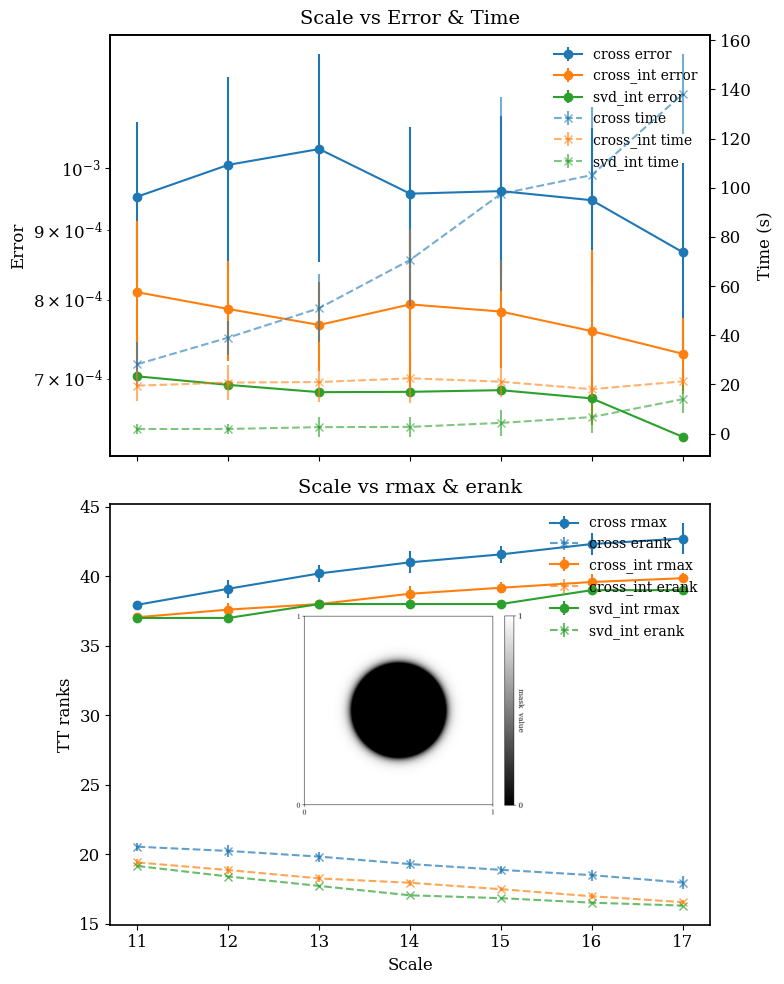

In [14]:
# 1) LaTeX style: serif font + Computer Modern mathtext
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# 2) Load & aggregate
#df = pd.read_csv('./data/mask_results.csv')
records = []
with open('./data/circle_results_lr.jsonl', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:      # skip empty or whitespace-only lines
            continue
        records.append(json.loads(line))

df = pd.DataFrame(records)

stats = (
    df.groupby(['method', 'scale'])
      .agg({
          'error': ['mean', 'std'],
          'time':  ['mean', 'std'],
          'rmax':  ['mean', 'std'],
          'erank': ['mean', 'std']
      })
      .reset_index()
)
stats.columns = [
    'method','scale',
    'error_mean','error_std',
    'time_mean','time_std',
    'rmax_mean','rmax_std',
    'erank_mean','erank_std'
]

methods = stats['method'].unique()
colors = sns.color_palette('tab10', n_colors=len(methods))

# 3) Create 2×1 figure, share x-axis
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
ax2 = ax1.twinx()

# --- Top: Error (log) & Time ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method]
    ax1.errorbar(
        d['scale'], d['error_mean'], yerr=d['error_std'],
        marker='o', linestyle='-', label=f'{method} error',
        color=colors[i]
    )
    ax2.errorbar(
        d['scale'], d['time_mean'], yerr=d['time_std'],
        marker='x', linestyle='--', label=f'{method} time',
        color=colors[i], alpha=0.6
    )

ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_ylabel('Error', fontsize=12)
ax2.set_ylabel('Time (s)',           fontsize=12)

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc='upper right', frameon=False, fontsize=10
)

ax1.set_title('Scale vs Error & Time', pad=8, fontsize=14)

# --- Bottom: rmax & erank ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method]
    ax3.errorbar(
        d['scale'], d['rmax_mean'], yerr=d['rmax_std'],
        marker='o', linestyle='-', label=f'{method} rmax',
        color=colors[i]
    )
    ax3.errorbar(
        d['scale'], d['erank_mean'], yerr=d['erank_std'],
        marker='x', linestyle='--', label=f'{method} erank',
        color=colors[i], alpha=0.7
    )

ax3.set_xlabel('Scale', fontsize=12)
ax3.set_ylabel('TT ranks', fontsize=12)
ax3.set_title('Scale vs rmax & erank', pad=8, fontsize=14)

# force integer ticks on the shared x-axis
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

ax3.legend(loc='upper right', frameon=False, fontsize=10)

# 4) Thicken spines
for ax in (ax1, ax2, ax3):
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# read in the image you want to embed
img_mid = mpimg.imread('./figures/circle.png')
# create an inset on ax3, anchored at its center
axins = inset_axes(
    ax3,
    width="50%",    # 30% of the width of ax3
    height="50%",   # 30% of the height of ax3
    loc='center'    # place it at the center of ax3
)

axins.imshow(img_mid)
axins.axis('off')    # hide its axes

# if you want the curves to draw *over* the inset, lower its z‐order:
axins.set_zorder(0)
ax3.set_zorder(1)
ax3.patch.set_visible(False)


plt.tight_layout()

# 5) Save as PDF for LaTeX
out_dir = './plots'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(
    os.path.join(out_dir, 'circle_mask_results.pdf'),
    format='pdf', bbox_inches='tight'
)

plt.show()

## Wing Mask

/tmp/ipykernel_589570/4100344935.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


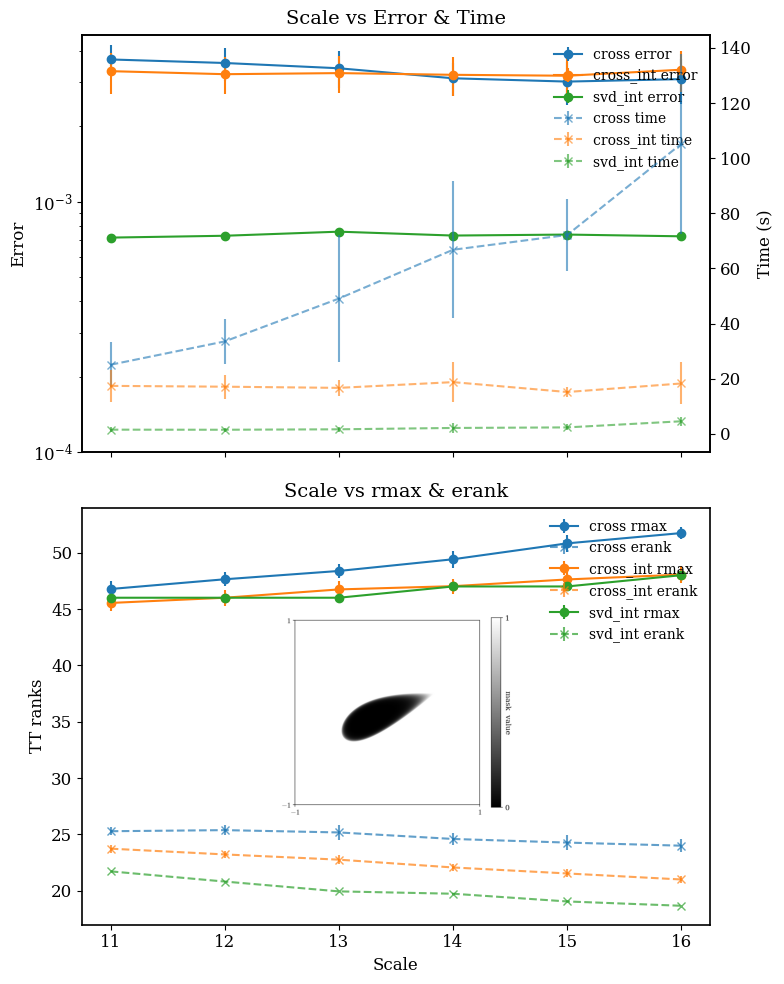

In [13]:
# 1) LaTeX style: serif font + Computer Modern mathtext
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# 2) Load & aggregate
#df = pd.read_csv('./data/mask_results.csv')
records = []
with open('./data/wing_results_lr.jsonl', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:      # skip empty or whitespace-only lines
            continue
        records.append(json.loads(line))

df = pd.DataFrame(records)

stats = (
    df.groupby(['method', 'scale'])
      .agg({
          'error': ['mean', 'std'],
          'time':  ['mean', 'std'],
          'rmax':  ['mean', 'std'],
          'erank': ['mean', 'std']
      })
      .reset_index()
)
stats.columns = [
    'method','scale',
    'error_mean','error_std',
    'time_mean','time_std',
    'rmax_mean','rmax_std',
    'erank_mean','erank_std'
]

methods = stats['method'].unique()
colors = sns.color_palette('tab10', n_colors=len(methods))

# 3) Create 2×1 figure, share x-axis
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
ax2 = ax1.twinx()

# --- Top: Error (log) & Time ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method]
    ax1.errorbar(
        d['scale'], d['error_mean'], yerr=d['error_std'],
        marker='o', linestyle='-', label=f'{method} error',
        color=colors[i]
    )
    ax2.errorbar(
        d['scale'], d['time_mean'], yerr=d['time_std'],
        marker='x', linestyle='--', label=f'{method} time',
        color=colors[i], alpha=0.6
    )

ax1.set_yscale('log')
ax1.set_yticks([1e-4, 1e-3])   
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_ylabel('Error', fontsize=12)
ax2.set_ylabel('Time (s)',           fontsize=12)

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc='upper right', frameon=False, fontsize=10
)

ax1.set_title('Scale vs Error & Time', pad=8, fontsize=14)

# --- Bottom: rmax & erank ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method]
    ax3.errorbar(
        d['scale'], d['rmax_mean'], yerr=d['rmax_std'],
        marker='o', linestyle='-', label=f'{method} rmax',
        color=colors[i]
    )
    ax3.errorbar(
        d['scale'], d['erank_mean'], yerr=d['erank_std'],
        marker='x', linestyle='--', label=f'{method} erank',
        color=colors[i], alpha=0.7
    )

ax3.set_xlabel('Scale', fontsize=12)
ax3.set_ylabel('TT ranks', fontsize=12)
ax3.set_title('Scale vs rmax & erank', pad=8, fontsize=14)

# force integer ticks on the shared x-axis
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

ax3.legend(loc='upper right', frameon=False, fontsize=10)

# 4) Thicken spines
for ax in (ax1, ax2, ax3):
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)


# --- after your bottom‐plot and spine‐thickening code ----


# read in the image you want to embed
img_mid = mpimg.imread('./figures/wing.png')
# create an inset on ax3, anchored at its center
axins = inset_axes(
    ax3,
    width="50%",    # 30% of the width of ax3
    height="50%",   # 30% of the height of ax3
    loc='center'    # place it at the center of ax3
)

axins.imshow(img_mid)
axins.axis('off')    # hide its axes

# if you want the curves to draw *over* the inset, lower its z‐order:
axins.set_zorder(0)
ax3.set_zorder(1)
ax3.patch.set_visible(False)

plt.tight_layout()

# 5) Save as PDF for LaTeX
out_dir = './plots'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(
    os.path.join(out_dir, 'wing_mask_results.pdf'),
    format='pdf', bbox_inches='tight'
)

plt.show()

## 3D mask

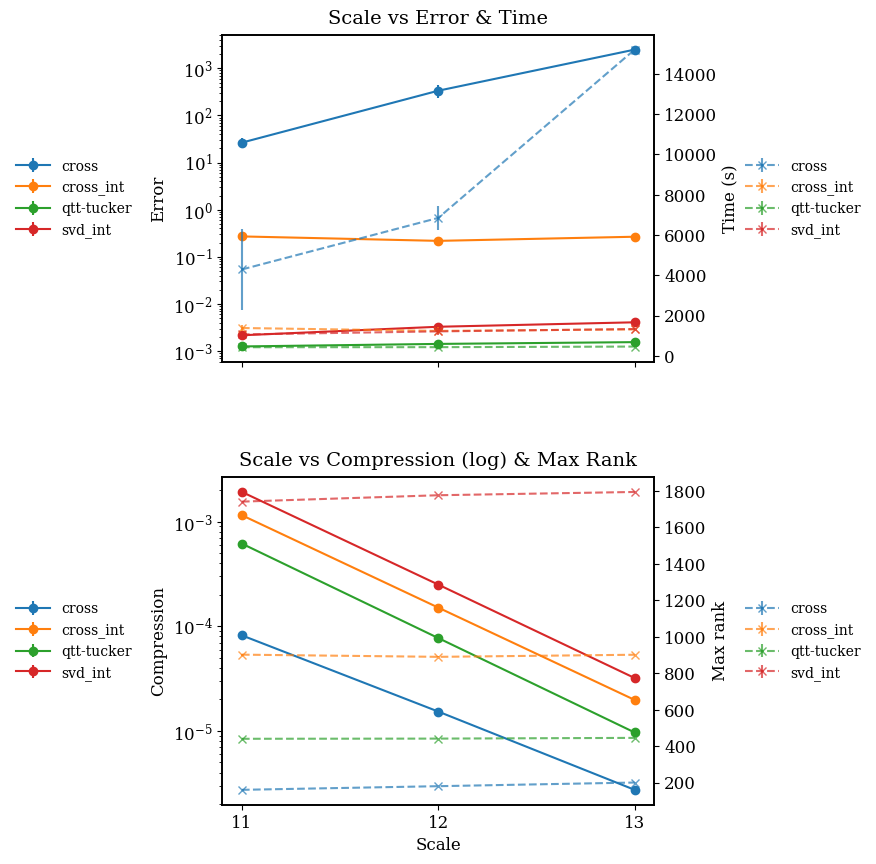

In [2]:
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogFormatterSciNotation

# 1) LaTeX style: serif font + Computer Modern mathtext
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# 2) Load & aggregate
records = []
with open('./data/3d_wing_c10_test.jsonl', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        records.append(json.loads(line))

df = pd.DataFrame(records)

stats = (
    df.groupby(['method', 'scale'])
      .agg({
          'error': ['mean', 'std'],
          'time':  ['mean', 'std'],
          'rmax':  ['mean', 'std'],
          'erank': ['mean', 'std']
      })
      .reset_index()
)

stats.columns = [
    'method','scale',
    'error_mean','error_std',
    'time_mean','time_std',
    'rmax_mean','rmax_std',
    'erank_mean','erank_std'
]

# Alias "erank" as "compression" for clarity in plotting
stats['compression_mean'] = stats['erank_mean']
stats['compression_std']  = stats['erank_std']

methods = stats['method'].unique()
colors = sns.color_palette('tab10', n_colors=len(methods))

# 3) Create 2×1 figure, share x-axis (white backgrounds)
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
fig.patch.set_facecolor('white')
ax1.set_facecolor('white'); ax3.set_facecolor('white')

ax2 = ax1.twinx()  # right axis for Time
ax4 = ax3.twinx()  # right axis for rmax
ax2.set_facecolor('white'); ax4.set_facecolor('white')

# --- Top: Error (log, left) & Time (right) ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')

    ax1.errorbar(
        d['scale'], d['error_mean'], yerr=d['error_std'],
        marker='o', linestyle='-', label=f'{method} • error',
        color=colors[i], zorder=3
    )
    ax2.errorbar(
        d['scale'], d['time_mean'], yerr=d['time_std'],
        marker='x', linestyle='--', label=f'{method} • time',
        color=colors[i], alpha=0.7, zorder=2
    )

ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_ylabel('Error', fontsize=12)
ax2.set_ylabel('Time (s)', fontsize=12)
ax1.set_title('Scale vs Error & Time', pad=8, fontsize=14)

# Separate legends: left for Error, right for Time
err_lines, err_labels = ax1.get_legend_handles_labels()
time_lines, time_labels = ax2.get_legend_handles_labels()

def strip_suffix(labels):
    # turn "Method • error" -> "Method"
    return [lab.split('•')[0].strip() for lab in labels]

leg_err = ax1.legend(
    err_lines, strip_suffix(err_labels),
    loc='center right', bbox_to_anchor=(-0.18, 0.5),
    ncol=1, frameon=False, fontsize=10, handlelength=2.5
)
leg_time = ax2.legend(
    time_lines, strip_suffix(time_labels),
    loc='center left', bbox_to_anchor=(1.18, 0.5),
    ncol=1, frameon=False, fontsize=10, handlelength=2.5
)

# --- Bottom: Compression (log, left) & Max rank (right) ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')

    ax3.errorbar(
        d['scale'], d['compression_mean'], yerr=d['compression_std'],
        marker='o', linestyle='-', label=f'{method} • compression',
        color=colors[i], zorder=3
    )
    ax4.errorbar(
        d['scale'], d['rmax_mean'], yerr=d['rmax_std'],
        marker='x', linestyle='--', label=f'{method} • max rank',
        color=colors[i], alpha=0.7, zorder=2
    )

ax3.set_yscale('log')
ax3.yaxis.set_major_formatter(LogFormatterSciNotation())
ax3.set_xlabel('Scale', fontsize=12)
ax3.set_ylabel('Compression', fontsize=12)
ax4.set_ylabel('Max rank', fontsize=12)
ax3.set_title('Scale vs Compression (log) & Max Rank', pad=8, fontsize=14)

# force integer ticks on the shared x-axis
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

# Separate legends: left for Compression, right for Max rank
comp_lines, comp_labels = ax3.get_legend_handles_labels()
rmax_lines, rmax_labels = ax4.get_legend_handles_labels()

leg_comp = ax3.legend(
    comp_lines, strip_suffix(comp_labels),
    loc='center right', bbox_to_anchor=(-0.18, 0.5),
    ncol=1, frameon=False, fontsize=10, handlelength=2.5
)
leg_rmax = ax4.legend(
    rmax_lines, strip_suffix(rmax_labels),
    loc='center left', bbox_to_anchor=(1.18, 0.5),
    ncol=1, frameon=False, fontsize=10, handlelength=2.5
)

# 4) Thicken spines
for ax in (ax1, ax2, ax3, ax4):
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# Make room on both sides for the outside legends
fig.subplots_adjust(left=0.28, right=0.82, hspace=0.35)

# 5) Save as PDF (white background)
out_dir = './plots'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(
    os.path.join(out_dir, '3d_wing_results.pdf'),
    format='pdf', bbox_inches='tight', facecolor='white'
)

plt.show()


# Turbulence

-0.4221034917164266


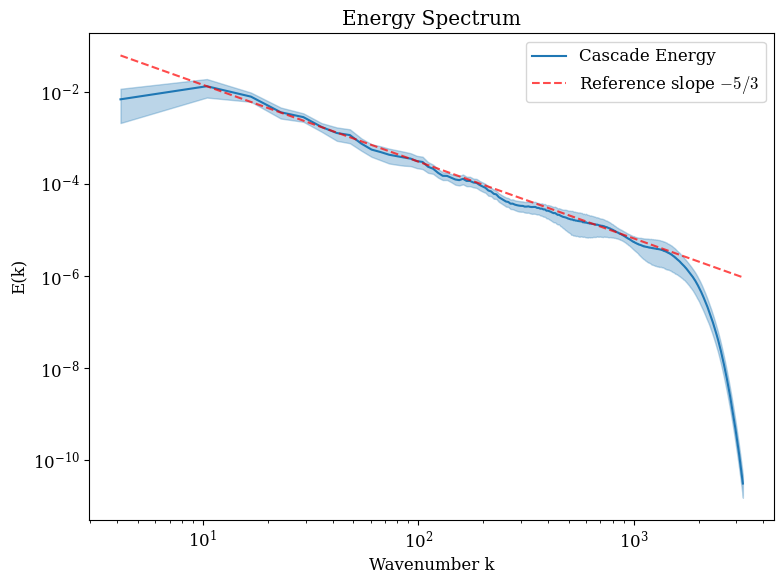

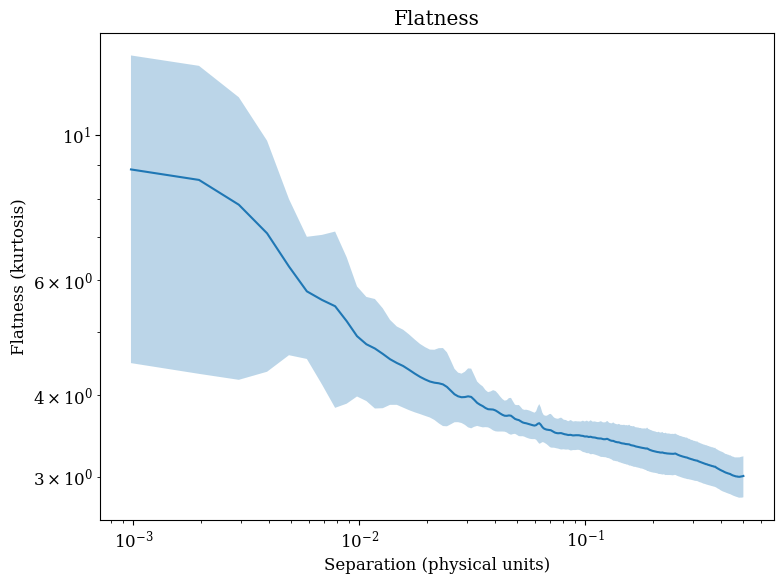

'\n# 2) Scaling exponent of the energy spectrum\nscaling = np.log(E_mean) / np.log(k)\n# Error propagation: σ_S = σ_E / (E_mean * |ln(k)|)\nsigma_scaling = E_std / (E_mean * np.abs(np.log(k)))\n# Plot scaling exponent with error shading\nplt.figure(figsize=(8, 6))\nplt.plot(k, scaling, label=\'Scaling exponent\')\nplt.fill_between(k, scaling - sigma_scaling, scaling + sigma_scaling, alpha=0.3, label=\'±1σ error\')\nplt.title("Scaling Exponent of Energy Spectrum")\nplt.show()\n'

In [9]:
# Load previously saved data
df_energy    = pd.read_csv('./data/turbulence/energy_comb10_e12.csv')
df_flatness  = pd.read_csv('./data/turbulence/flatness_comb10_e12.csv')

# Drop rows where separation is NaN
# df_flatness = df_flatness.dropna(subset=['separation'])

# 1) Energy statistics: mean and std over runs at each k_center
energy_stats = df_energy.groupby('k_center')['E_k'].agg(['mean', 'std']).reset_index()
k      = energy_stats['k_center'].values
E_mean = energy_stats['mean'].values
E_std  = energy_stats['std'].values

# --- Linear fit on the window where 2 <= k <= 300 ---
# mask = (k >= 2) & (k <= 300)
# log_k_fit = np.log(k[mask])
# log_E_fit = np.log(E_mean[mask])
# slope, intercept, *_ = linregress(log_k_fit, log_E_fit)
# fit_line = np.exp(intercept + slope * np.log(k))  # for full overlay

# --- Reference line with slope -5/3 ---
k_ref = np.linspace(k.min(), k.max(), 200)
ref_slope = -5/3
# Choose reference level so that it matches roughly the curve height
ref_intercept = np.log(E_mean[ (k > 10) & (k < 400) ][0]) - ref_slope * np.log(k[(k > 10) & (k < 400)][0])
print(ref_intercept)
ref_line = np.exp(ref_intercept) * k_ref**(ref_slope)

# --- Plot ---
plt.figure(figsize=(8, 6))
plt.loglog(k, E_mean, label='Cascade Energy', color='tab:blue')
plt.fill_between(k, E_mean - E_std, E_mean + E_std, alpha=0.3, color='tab:blue')
# plt.loglog(k, fit_line, '--', color='red', alpha=0.5, label=f"Fit: slope = {slope:.2f}")
plt.loglog(k_ref, ref_line, '--', color='red', alpha=0.7, label=r"Reference slope $-5/3$")

plt.xlabel("Wavenumber k")
plt.ylabel("E(k)")
plt.title("Energy Spectrum")
plt.legend()
plt.tight_layout()
plt.savefig("./plots/energy.pdf", format='pdf')
plt.show()

# 3) Flatness statistics: mean and std over runs at each separation
flat_stats = df_flatness.groupby('separation')['flatness'].agg(['mean', 'std']).reset_index()
s       = flat_stats['separation'].values
F_mean  = flat_stats['mean'].values
F_std   = flat_stats['std'].values

# Plot flatness vs separation in log-log space
plt.figure(figsize=(8, 6))
plt.loglog(s, F_mean, label='Cascade Flatness')
plt.fill_between(s, F_mean - F_std, F_mean + F_std, alpha=0.3)
plt.xlabel("Separation (physical units)")
plt.ylabel("Flatness (kurtosis)")
plt.title("Flatness")
#plt.legend()
plt.tight_layout()
plt.savefig("./plots/flatness.pdf", format='pdf')
plt.show()

"""
# 2) Scaling exponent of the energy spectrum
scaling = np.log(E_mean) / np.log(k)
# Error propagation: σ_S = σ_E / (E_mean * |ln(k)|)
sigma_scaling = E_std / (E_mean * np.abs(np.log(k)))
# Plot scaling exponent with error shading
plt.figure(figsize=(8, 6))
plt.plot(k, scaling, label='Scaling exponent')
plt.fill_between(k, scaling - sigma_scaling, scaling + sigma_scaling, alpha=0.3, label='±1σ error')
plt.title("Scaling Exponent of Energy Spectrum")
plt.show()
"""


## rank growth

In [ ]:
df_c = pd.read_csv("./data/turbulence/rcg_250_10_e8_o2.csv")
df_c = df_c[df_c['Dimension'] <= 12]
df_energy_c   = pd.read_csv('./data/turbulence/energy_comb10_e12.csv')
df_flatness_c  = pd.read_csv('./data/turbulence/flatness_comb10_e12.csv')


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter, LogLocator, LogFormatterMathtext
from scipy.stats import linregress
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg

from pysciplottk import EasyPlotter

# ── Snapshot for panel (a)
image = mpimg.imread("snapshot_cube.png")

# ====== Original (QTT-I) ======
df = pd.read_csv("./data/turbulence/rqttV5c2_1em8_p.csv")
stats  = df.groupby("Dimension")["MaxRank"].agg(["mean", "std"]).reset_index()
stats2 = df.groupby("Dimension")["ERank"].agg(["mean", "std"]).reset_index()
M         = stats["Dimension"].values
chi_mean  = stats["mean"].values
chi_std   = stats["std"].values
erank_mean = stats2["mean"].values
erank_std  = stats2["std"].values

# χ fit (QTT-I)
slope, intercept, *_ = linregress(df["Dimension"], df["MaxRank"])

# Flatness (QTT-I)
df_flatness = pd.read_csv("./data/turbulence/qttflatness10_8.csv")
flat_stats = df_flatness.groupby("separation")["flatness"].agg(["mean", "std"]).reset_index()
s      = flat_stats["separation"].values
F_mean = flat_stats["mean"].values
F_std  = flat_stats["std"].values

# Energy (QTT-I)
df_energy = pd.read_csv("./data/turbulence/qttenergy10_c.csv")
energy_stats = df_energy.groupby("k_center")["E_k"].agg(["mean", "std"]).reset_index()
k     = energy_stats["k_center"].values
E_mea = energy_stats["mean"].values
E_std = energy_stats["std"].values

# ====== Combined (QTT-T) ======
df_c = pd.read_csv("./data/turbulence/rcg_200_10_e8_o2.csv")  # updated file
df_c = df_c[df_c["Dimension"] <= 12]

# χ stats + fit (QTT-T)
stats_c   = df_c.groupby("Dimension")["MaxRank"].agg(["mean","std"]).reset_index()
M_c        = stats_c["Dimension"].values
chi_mean_c = stats_c["mean"].values
chi_std_c  = stats_c["std"].values
slope_c, intercept_c, *_ = linregress(df_c["Dimension"], df_c["MaxRank"])

# Energy (QTT-T)
df_energy_c    = pd.read_csv("./data/turbulence/energy_comb10_e12.csv")
energy_stats_c = df_energy_c.groupby("k_center")["E_k"].agg(["mean","std"]).reset_index()
k_c     = energy_stats_c["k_center"].values
E_mea_c = energy_stats_c["mean"].values
E_std_c = energy_stats_c["std"].values

# Flatness (QTT-T)
df_flatness_c = pd.read_csv("./data/turbulence/flatness_comb10_e12.csv")
flat_stats_c = df_flatness_c.groupby("separation")["flatness"].agg(["mean","std"]).reset_index()
s_c      = flat_stats_c["separation"].values
F_mean_c = flat_stats_c["mean"].values
F_std_c  = flat_stats_c["std"].values

# ====== Power-law guides k^{-5/3} ======
ref_slope = -5/3
def power_guide(x, y, slope, lo=10, hi=400):
    x = np.asarray(x); y = np.asarray(y)
    mask = (x > max(lo, x.min()*1.5)) & (x < min(hi, x.max()/1.5))
    idx = np.where(mask)[0][0] if np.any(mask) else len(x)//2
    b = np.log(y[idx]) - slope*np.log(x[idx])
    xr = np.linspace(x.min(), x.max(), 200)
    yr = np.exp(b) * xr**slope
    return xr, yr

k_ref,   ref_line   = power_guide(k,   E_mea,   ref_slope)
k_ref_c, ref_line_c = power_guide(k_c, E_mea_c, ref_slope)

# ──────────────────────────────────────────────────────────────────────
# SIZE CONFIG (exactly as requested)
plotter = EasyPlotter("synthetic_results.pdf", "latex,revtex")
fig = plotter.wide_figure()
fig.set_size_inches(w=14.0, h=4)
gs = GridSpec(1, 3, figure=fig, width_ratios=[1.0, 1.0, 1.0])
gs.update(left=0.043, right=0.94, bottom=0.23, top=0.92, wspace=0.16)

plt.rcParams.update({
    "lines.linewidth": 2.5,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 16,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

axs = [fig.add_subplot(gs[0, i]) for i in range(3)]

# ── (a) Energy spectrum ──────────────────────────────────────────────
# Curves
line_I,  = axs[0].loglog(k,   E_mea,   color="tab:blue",  label="QTT-I")
axs[0].fill_between(k, E_mea - E_std, E_mea + E_std, alpha=0.30, color="tab:blue")
line_T,  = axs[0].loglog(k_c, E_mea_c, color="tab:green", label="QTT-T")
axs[0].fill_between(k_c, E_mea_c - E_std_c, E_mea_c + E_std_c, alpha=0.22, color="tab:green")

# Two k^{-5/3} guides (no legend labels)
axs[0].loglog(k_ref,   ref_line,   "--", color="tab:red")
axs[0].loglog(k_ref_c, ref_line_c, "--", color="tab:purple")

# Keep legend for the two data curves only
axs[0].legend(handles=[line_I, line_T], frameon=False, loc="upper right")

# Lower-right in-axes label for the guides (two colored swatches + one text)
x0, x1 = 0.78, 0.84         # swatch start/end (axes coords)
yR, yP = 0.09, 0.04         # stacked rows near lower-right
axs[0].plot([x0, x1], [yR, yR], transform=axs[0].transAxes, color="tab:red", linestyle="--",   lw=2, clip_on=False)
axs[0].plot([x0, x1], [yP, yP], transform=axs[0].transAxes, color="tab:purple", lw=2, linestyle="--",clip_on=False)
axs[0].text(0.85, 0.057, r"$k^{-5/3}$", transform=axs[0].transAxes,
            ha="left", va="center", fontsize=12, color="0.15")

axs[0].set_xlabel(r"$k = \sqrt{k_x^2 + k_y^2 + k_z^2}$")
axs[0].set_title(r"\textbf{a.} Energy Spectrum $E(k)$")


# Insert the snapshot image EXACTLY like your working example (after plotting)
inset_ax = inset_axes(
    axs[0],
    width="55%",
    height="55%",
    loc="lower left",
    bbox_to_anchor=(-0.1, -0.02, 1.1, 1.1),
    bbox_transform=axs[0].transAxes,
)
inset_ax.imshow(image)
inset_ax.axis("off")

# ── (b) Flatness ─────────────────────────────────────────────────────
axs[1].loglog(s,   F_mean,   color="tab:blue",  label="QTT-I")
axs[1].fill_between(s, F_mean - F_std, F_mean + F_std, alpha=0.30, color="tab:blue")
axs[1].loglog(s_c, F_mean_c, color="tab:green", label="QTT-T")
axs[1].fill_between(s_c, F_mean_c - F_std_c, F_mean_c + F_std_c, alpha=0.22, color="tab:green")

axs[1].set_xlabel(r"Separation $r$")
axs[1].axhline(y=min(F_mean.min(), F_mean_c.min()), color="black", linestyle="--",
               alpha=0.7, label=r"zero-intermittency")
axs[1].set_title(r"\textbf{b.} Flatness (kurtosis)")
axs[1].legend(frameon=False, loc="upper right")
for axis in [axs[1].yaxis]:
    axis.set_major_formatter(FuncFormatter(lambda y, _: "{:g}".format(y)))
    axis.set_minor_formatter(FuncFormatter(lambda y, _: "{:g}".format(y)))

# ── (c) χ vs M with BOTH compressions ───────────────────────────────
# χ points (no labels)
axs[2].errorbar(M,  chi_mean,  yerr=chi_std,  fmt="o", color="tab:blue")
axs[2].errorbar(M_c, chi_mean_c, yerr=chi_std_c, fmt="s", color="tab:green")

# χ slope lines + CENTER-TOP text labels (no bullets/lines)
axs[2].plot(M,  intercept + slope*M,   "--", color="crimson")
axs[2].plot(M_c, intercept_c + slope_c*M_c, "--", color="tab:olive")
axs[2].text(0.50, 0.96, rf"$\chi \propto {slope:.1f}M$ (QTT\!-\!I)",
            transform=axs[2].transAxes, ha="center", va="top",
            color="crimson", fontsize=13)
axs[2].text(0.50, 0.88, rf"$\chi \propto {slope_c:.1f}M$ (QTT\!-\!T)",
            transform=axs[2].transAxes, ha="center", va="top",
            color="tab:olive", fontsize=13)

# Compression (right axis)
comp_ratio     = (3 * M  * erank_mean**2) / (2 ** (3 * M))
comp_ratio_std = (3 * M  * erank_std**2)  / (2 ** (3 * M))
comp_I    = comp_ratio * 100.0
comp_I_lo = np.clip((comp_ratio - comp_ratio_std) * 100.0, 1e-12, None)
comp_I_hi = (comp_ratio + comp_ratio_std) * 100.0

comp_stats = df_c.groupby("Dimension")["compression"].agg(["mean","std"]).reset_index()
Mc        = comp_stats["Dimension"].values
comp_T    = comp_stats["mean"].values
comp_Tstd = comp_stats["std"].values
if comp_T.max() <= 1.5:
    comp_T    = comp_T * 100.0
    comp_Tstd = comp_Tstd * 100.0
comp_T_lo = np.clip(comp_T - comp_Tstd, 1e-12, None)
comp_T_hi = comp_T + comp_Tstd

ax_r = axs[2].twinx()
ax_r.plot(M,  comp_I, "-o",  ms=4, color="tab:orange")
ax_r.fill_between(M,  comp_I_lo, comp_I_hi, color="tab:orange", alpha=0.12, linewidth=0)
ax_r.plot(Mc, comp_T, "-^",  ms=4, color="sienna")
ax_r.fill_between(Mc, comp_T_lo, comp_T_hi, color="sienna", alpha=0.10, linewidth=0)
ax_r.axhline(y=100, color="gray", linestyle="--", alpha=0.5, linewidth=1)

# Robust log limits; clamp to 1e-4 min (no 1e-10 ticks)
all_low  = np.array([comp_I_lo.min(), comp_T_lo.min(), 1e-4])
all_high = np.array([comp_I_hi.max(), comp_T_hi.max(), 100.0])
cmin = float(all_low.min())
cmax = float(all_high.max())
lo_dec = 10 ** np.floor(np.log10(cmin))
hi_dec = 10 ** np.ceil(np.log10(cmax))
ax_r.set_yscale("log")
ax_r.set_ylim(lo_dec, hi_dec)
ax_r.yaxis.set_major_locator(LogLocator(base=10))
ax_r.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
ax_r.yaxis.set_minor_formatter(FuncFormatter(lambda *_: ""))

# Compression labels (CENTER-LEFT on right axis) using short colored line swatches
def label_with_line(ax, y_ax, color, text):
    x0, x1 = 0.05, 0.15
    ax.plot([x0, x1], [y_ax, y_ax], transform=ax.transAxes, color=color, lw=2, clip_on=False)
    ax.text(x1 + 0.02, y_ax, text, transform=ax.transAxes,
            ha="left", va="center", color="black", fontsize=11)

label_with_line(ax_r, 0.55, "tab:orange", "Comp. (\%) QTT-I")
label_with_line(ax_r, 0.45, "sienna",     "Comp. (\%) QTT-T")

# Titles/labels (no χ label on y-axis)
axs[2].set_title(r"\textbf{c.} TT Bond dimension ($\chi$)")
axs[2].set_xlabel("No. of scales $M$")
# axs[2].set_ylabel(r"$\chi$")  # intentionally omitted
axs[2].xaxis.set_major_locator(plt.MaxNLocator(6, integer=True))
axs[2].yaxis.set_major_locator(plt.MaxNLocator(4))

# Final layout
gs.tight_layout(fig, pad=0.0)
plotter.save()


/tmp/ipykernel_1373610/3722067266.py:223: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  gs.tight_layout(fig, pad=0.0)
